**Table of contents**<a id='toc0_'></a>    
- [Photoswitching fingerprints: modulating OFF time](#toc1_)    
  - [Data preparation](#toc1_1_)    
  - [Data generation](#toc1_2_)    
  - [Reading the data](#toc1_3_)    
  - [Fitting the data](#toc1_4_)    
    - [Using the fingerprints and fitting a CDF](#toc1_4_1_)    
    - [Using the bleaching times and fitting a PDF](#toc1_4_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Photoswitching fingerprints: modulating OFF time](#toc0_)

In [ ]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr
import src.routines as ro

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

## <a id='toc1_1_'></a>[Data preparation](#toc0_)

In [2]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=3, count=1, shape="triangle"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

irradiance=2.5
wavelength=640
bleaching=True
energy_transfer=True
reducing_agent="mea"
concentration=100
ph=7.5

In [ ]:
transitions = fluorophore_system.load_transitions(
    irradiance=irradiance,
    wavelength=wavelength,
    bleaching=bleaching,
    energy_transfer=energy_transfer,
    dstorm=True,
    dstorm_parameters={'reducing_agent':reducing_agent,
    'concentration':concentration,
    'ph':ph},
)
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set = transition_set.adjust_rates({5:2e4, 4:1e7})
transition_set.finalize()

## <a id='toc1_2_'></a>[Data generation](#toc0_)

In [4]:
rng = np.random.default_rng(1)

In [5]:
transition_set = transition_set.adjust_rates({12:2e-2})
transition_set.finalize()
path = r"D:\simulation_data\off_time"
_, _ = ro.fingerprint_analysis(transition_set, batches=1, 
batch_size=500, filepath=path, filename='th_elim_2e-2', seed=rng, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_5")

In [6]:
transition_set = transition_set.adjust_rates({12:2e-1})
transition_set.finalize()
path = r"D:\simulation_data\off_time"
_, _ = ro.fingerprint_analysis(transition_set, batches=1, 
batch_size=500, filepath=path, filename='th_elim_2e-1', seed=rng, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_5")

In [7]:
transition_set = transition_set.adjust_rates({12:2e0})
transition_set.finalize()
path = r"D:\simulation_data\off_time"
_, _ = ro.fingerprint_analysis(transition_set, batches=1, 
batch_size=300, filepath=path, filename='th_elim_2e0', seed=rng, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_5")

In [ ]:
transition_set = transition_set.adjust_rates({12:2e1})
transition_set.finalize()
path = r"D:\simulation_data\off_time"
_, _ = ro.fingerprint_analysis(transition_set, batches=1, 
batch_size=300, filepath=path, filename='th_elim_2e1', seed=rng, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_5")

## <a id='toc1_3_'></a>[Reading the data](#toc0_)

In [ ]:
identifiers = ['2e-2', '2e-1', '2e0', '2e1']
bleaching_times_all = []
fingerprints_all = []

for _ in identifiers:
    fingerprints_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
folder_path = r"C:\Users\vie43sq\Desktop\Simulations\simulation_data\off_time"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_all[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                break

for i, fingerprint in enumerate(fingerprints_all):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all[i] = fingerprint

## <a id='toc1_4_'></a>[Fitting the data](#toc0_)

### <a id='toc1_4_1_'></a>[Using the fingerprints and fitting a CDF](#toc0_)

In [ ]:
from lmfit import Model, Parameters

model = Model(dist.two_expon_mixture_cdf)
params = Parameters()
params.add('p', value=0.5, min=0, max=1)
params.add('lambda1', value=1, min=0)
params.add('lambda2', value=0.5, min=0)

parameters_all_fit_cdf = []
for fingerprint in fingerprints_all:
    result = model.fit(fingerprint, params, x=np.linspace(0, 300, 300001))
    parameters_all_fit_cdf.append([param.value for param in result.params.values()])

: 

### <a id='toc1_4_2_'></a>[Using the bleaching times and fitting a PDF](#toc0_)

In [19]:
parameters_all_fit_pdf = []
for bl_times in bleaching_times_all:
    pi, lambda1, lambda2 = dist.estimate_mixture_parameters(
        data=bl_times[:, 0][~np.isnan(bl_times[:, 0])],
        initial_guess=[0.5, 1, 1.1],
        bounds=([0, 1], [0, None], [0, None]),
        truncation_low=0,
        truncation_up=300,
        number_no_events=0,  # np.count_nonzero(np.isnan(bl_times[:, 0])),
        method='powell', 
    )
    parameters_all_fit_pdf.append([pi, lambda1, lambda2])

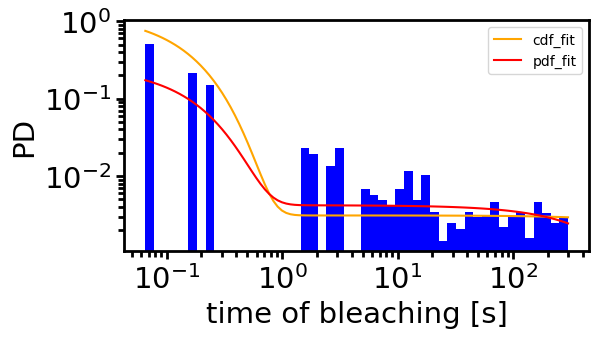

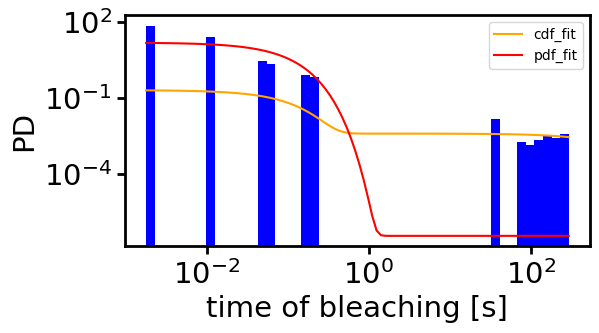

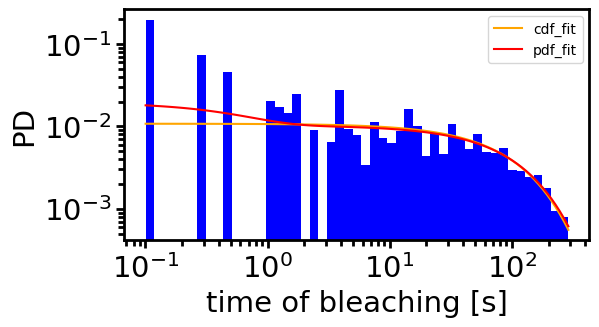

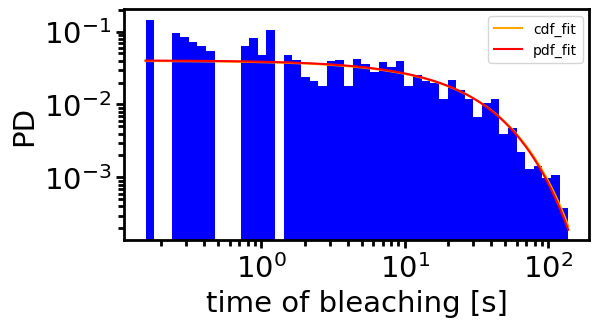

In [20]:
for (bl_times, parameters_1, parameters_2) in zip(bleaching_times_all, parameters_all_fit_pdf, parameters_all_fit_cdf):
    pi_fit_1, lambda1_fit_1, lambda2_fit_1 = parameters_1
    pi_fit_2, lambda1_fit_2, lambda2_fit_2 = parameters_2
    data = bl_times[:, 0][~np.isnan(bl_times[:, 0])]
    bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
    ax = fi.universal_figure(type_='hist', bins=bins, data=data, density=True) 
    x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 100)
    fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_2, lambda2_fit_2, pi_fit_2)], 
                        axes=ax[0], color='orange', label='cdf_fit')
    fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_1, lambda2_fit_1, pi_fit_1)], 
                        type_='line', axes=ax[0], yscale='log', xscale='log', 
                        xlabel='time of bleaching [s]', ylabel='PD', color='red', label='pdf_fit', legend=True)